# Stage 03 - Python Fundamentals

This notebook uses NumPy and pandas to explore the provided category-value dataset and save reproducible outputs.

In [1]:
from pathlib import Path
import sys

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'raw' / 'starter_data.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find starter_data.csv from the current working directory.')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

PosixPath('/Users/zhangyuang/Desktop/py_file/bootcamp/homework/homework3')

## 1. NumPy operations and vectorization

In [2]:
import numpy as np
from timeit import timeit

numbers = np.array([1, 2, 3, 4, 5])
elementwise_result = numbers * 3 + 1
print('Original:', numbers)
print('Elementwise result (x * 3 + 1):', elementwise_result)

large_array = np.arange(100_000)
loop_seconds = timeit('[value * 2 for value in large_array]', globals=globals(), number=20)
vectorized_seconds = timeit('large_array * 2', globals=globals(), number=20)
print(f'Loop time: {loop_seconds:.4f} seconds')
print(f'Vectorized time: {vectorized_seconds:.4f} seconds')
print(f'Vectorized faster: {vectorized_seconds < loop_seconds}')

Original: [1 2 3 4 5]
Elementwise result (x * 3 + 1): [ 4  7 10 13 16]
Loop time: 0.0965 seconds
Vectorized time: 0.0007 seconds
Vectorized faster: True


## 2. Load and inspect the dataset

In [3]:
import pandas as pd

data_path = PROJECT_ROOT / 'data' / 'raw' / 'starter_data.csv'
df = pd.read_csv(data_path, parse_dates=['date'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     object        
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 368.0+ bytes


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


## 3. Summary statistics and category aggregation

In [4]:
numeric_summary = df[['value']].describe()
numeric_summary

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [5]:
from src.utils import get_summary_stats

category_summary = get_summary_stats(df)
category_summary

,category,count,total,mean,minimum,maximum
0,A,4,46,11.500000,10,13
1,B,3,47,15.666667,14,18
2,C,3,83,27.666667,25,30


## 4. Save the output and bonus chart

Saved summary to: /Users/zhangyuang/Desktop/py_file/bootcamp/homework/homework3/data/processed/summary.csv


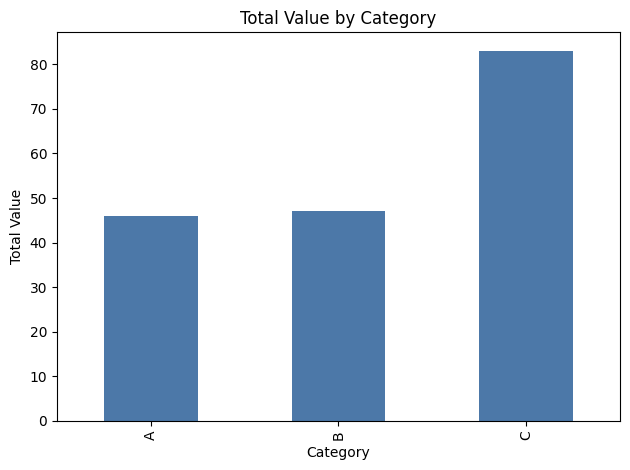

Saved bonus chart to: /Users/zhangyuang/Desktop/py_file/bootcamp/homework/homework3/data/processed/value_by_category.png


In [6]:
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
summary_path = processed_dir / 'summary.csv'
category_summary.to_csv(summary_path, index=False)
print(f'Saved summary to: {summary_path}')

import matplotlib.pyplot as plt
ax = category_summary.plot.bar(x='category', y='total', legend=False, color='#4C78A8')
ax.set(title='Total Value by Category', xlabel='Category', ylabel='Total Value')
plt.tight_layout()
plot_path = processed_dir / 'value_by_category.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Saved bonus chart to: {plot_path}')

## Conclusion

The reusable function produces a category-level output that can be refreshed whenever new data arrives. This sample is descriptive only; more history and business context are needed before explaining or forecasting category differences.